In [27]:
from langgraph.graph import StateGraph,START,END
from typing import Annotated,TypedDict
from langgraph.graph.message import add_messages
class state(TypedDict):
    messages:Annotated[list,add_messages]
graphbuiler=StateGraph(state)

In [28]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [29]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.3-70b-versatile")

In [30]:
def chatbot(state:state):
    return {"messages":[llm.invoke(state["messages"])]}

In [31]:
graphbuiler=StateGraph(state)
graphbuiler.add_node("llmchatbot",chatbot)
graphbuiler.add_edge(START,"llmchatbot")
graphbuiler.add_edge("llmchatbot",END)

graph=graphbuiler.compile()


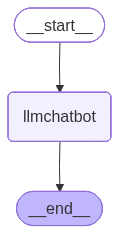

In [32]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [33]:
response=graph.invoke({"messages":"hi"})
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [36]:
for event in graph.stream({"messages":"hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you might have. How about you? Is there something I can help you with today?


In [40]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_result=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.langchain.com/langgraph',
   'title': 'LangGraph: Agent Orchestration Framework for Reliable AI Agents',
   'content': '[![Image 7](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6989c02453d869396317aaa3_updated-1.svg) deepagents Build long-running agents for complex tasks](https://www.langchain.com/deep-agents)[![Image 8](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6989c024409fcfc7e5b8f78f_Frame%202147254707-1.svg) langchain Quick start agents with any model provider](https://www.langchain.com/langchain)[![Image 9](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6989c024c2d98286a8fb058f_Frame%202147255166-1.svg) langgraph Build reliable agents with low-level control](https://www.langchain.com/langgraph). ![Image 11](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/699ea59bbdd3163a372a1124_langgraph%20ilu.svg)

In [41]:
def multiply(a:int,b:int)->int:
    """multiply a and b
    args:
        a(int):first int
        b(int):second int

    returns
        int:output int
    """
    return a*b

In [42]:
tools=[tool,multiply]

In [43]:
llm_with_tool=llm.bind_tools(tools)


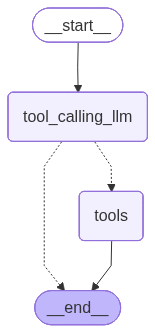

In [46]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph,START,END

def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)

graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

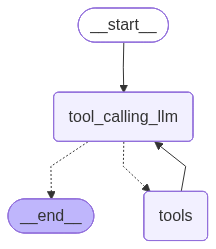

In [47]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph,START,END

def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

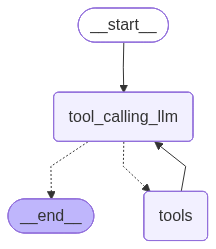

In [49]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
config={
    "configurable":
    {
        "thread_id":"1"
    }
}

response = graph.invoke(
    {"messages": "Hi my name is omkar"},
    config=config
)

print(response)

{'messages': [HumanMessage(content='Hi my name is omkar', additional_kwargs={}, response_metadata={}, id='c5a29ffa-0233-4ad5-9b3e-fbb7103d8fb7'), AIMessage(content="Hello Omkar, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1788, 'total_tokens': 1815, 'completion_time': 0.074140411, 'completion_tokens_details': None, 'prompt_time': 0.161758898, 'prompt_tokens_details': None, 'queue_time': 0.163266613, 'total_time': 0.235899309}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb107-b684-7c91-b0f2-994bc397a788-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1788, 'output_tokens': 27, 'total_tokens': 1815})]}
